In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import matplotlib.pyplot as plt
import itertools
import numpy as np
import holidays

c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [9]:
df = pd.read_csv("C:/Users/alexa/OneDrive/Documentos/Curso5/Proyectos4/casa_60_clima.csv", parse_dates=True)
df = df.drop(columns=['fecha'])
# Renombrar columnas para Prophet
df.rename(columns={'consumo_kWh': 'y', 'timestamp': 'ds'}, inplace=True)

# Exploración de Variables del Dataset
En esta sección, exploraremos las variables disponibles en el dataset para determinar cuáles son útiles para el modelo Prophet.

In [10]:
# Ver las primeras filas del dataset
df.head()

,y,coste_euros,temperatura,ds,altitud,tmed,tmin,tmax,velmedia,racha,...,horatmin_varias,horatmin_minutos,horatmax_varias,horaracha_varias,horaPresMax_varias,horaPresMin_varias,prec_inapreciable,prec_valor,prec_log,hora
0,66.0,11.02794,13.63,2017-12-15 12:00:00,408,8.8,5.4,12.3,0.8,16.4,...,0,1439,0,0,0,0,0,0.0,0.0,12:00:00
1,71.0,6.39142,13.79,2017-12-15 13:00:00,408,8.8,5.4,12.3,0.8,16.4,...,0,1439,0,0,0,0,0,0.0,0.0,13:00:00
2,76.0,6.89168,14.04,2017-12-15 14:00:00,408,8.8,5.4,12.3,0.8,16.4,...,0,1439,0,0,0,0,0,0.0,0.0,14:00:00
3,78.0,8.18064,13.94,2017-12-15 15:00:00,408,8.8,5.4,12.3,0.8,16.4,...,0,1439,0,0,0,0,0,0.0,0.0,15:00:00
4,67.0,10.95785,13.52,2017-12-15 16:00:00,408,8.8,5.4,12.3,0.8,16.4,...,0,1439,0,0,0,0,0,0.0,0.0,16:00:00


In [11]:
# Verificar tipos de datos y valores nulos
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19261 entries, 0 to 19260
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   y                   19261 non-null  float64
 1   coste_euros         19261 non-null  float64
 2   temperatura         19261 non-null  float64
 3   ds                  19261 non-null  object 
 4   altitud             19261 non-null  int64  
 5   tmed                19261 non-null  float64
 6   tmin                19261 non-null  float64
 7   tmax                19261 non-null  float64
 8   velmedia            19261 non-null  float64
 9   racha               19261 non-null  float64
 10  sol                 19261 non-null  float64
 11  presMax             19261 non-null  float64
 12  presMin             19261 non-null  float64
 13  hrMedia             19261 non-null  float64
 14  anio                19261 non-null  int64  
 15  mes                 19261 non-null  int64  
 16  dia 

y                     0
coste_euros           0
temperatura           0
ds                    0
altitud               0
tmed                  0
tmin                  0
tmax                  0
velmedia              0
racha                 0
sol                   0
presMax               0
presMin               0
hrMedia               0
anio                  0
mes                   0
dia                   0
dia_semana            0
estacion              0
horatmin_varias       0
horatmin_minutos      0
horatmax_varias       0
horaracha_varias      0
horaPresMax_varias    0
horaPresMin_varias    0
prec_inapreciable     0
prec_valor            0
prec_log              0
hora                  0
dtype: int64

In [12]:
# Estadísticas descriptivas para entender las variables
df.describe()

,y,coste_euros,temperatura,altitud,tmed,tmin,tmax,velmedia,racha,sol,...,estacion,horatmin_varias,horatmin_minutos,horatmax_varias,horaracha_varias,horaPresMax_varias,horaPresMin_varias,prec_inapreciable,prec_valor,prec_log
count,19261.000000,19261.000000,19261.000000,19261.0,19261.000000,19261.000000,19261.00000,19261.000000,19261.000000,19261.000000,...,19261.000000,19261.000000,19261.000000,19261.000000,19261.0,19261.000000,19261.000000,19261.000000,19261.000000,19261.000000
mean,53.658429,10.256222,17.019715,408.0,15.938892,12.042023,19.83545,4.038461,11.466674,7.668844,...,2.434816,0.188204,450.930429,0.119620,0.0,0.181922,0.289133,0.088469,0.004423,0.004316
std,21.949134,6.220433,5.243200,0.0,6.308408,5.992321,6.78963,1.797111,3.521780,3.754612,...,1.154867,0.390885,494.900031,0.324525,0.0,0.385790,0.453372,0.283983,0.014199,0.013856
min,0.000000,0.000000,3.830000,408.0,-0.400000,-2.400000,1.70000,0.600000,4.400000,0.000000,...,1.000000,0.000000,-1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34.000000,5.350120,12.830000,408.0,10.800000,7.400000,14.30000,2.800000,8.900000,5.200000,...,1.000000,0.000000,59.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,8.995250,15.480000,408.0,14.600000,10.700000,18.80000,3.900000,10.800000,8.500000,...,2.000000,0.000000,293.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
75%,73.000000,13.330400,22.010000,408.0,21.200000,17.100000,25.10000,5.000000,13.300000,10.300000,...,3.000000,0.000000,478.000000,0.000000,0.0,0.000000,1.000000,0.000000,0.000000,0.000000
max,108.000000,33.111000,30.180000,408.0,32.600000,27.500000,37.70000,15.600000,28.900000,13.900000,...,4.000000,1.000000,1439.000000,1.000000,0.0,1.000000,1.000000,1.000000,0.050000,0.048790


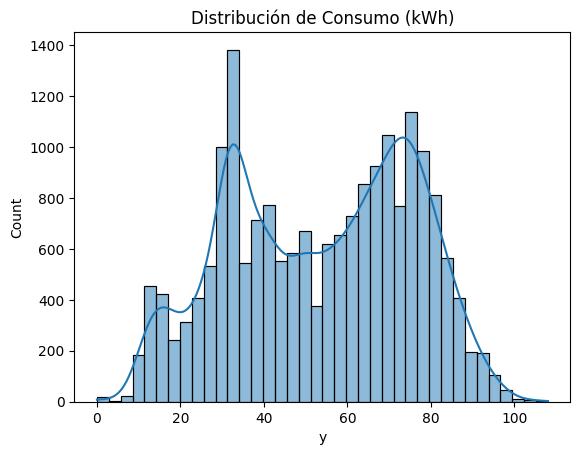

In [13]:
# Visualizar la distribución de la variable objetivo (consumo_kWh)
sns.histplot(df['y'], kde=True)
plt.title('Distribución de Consumo (kWh)')
plt.show()

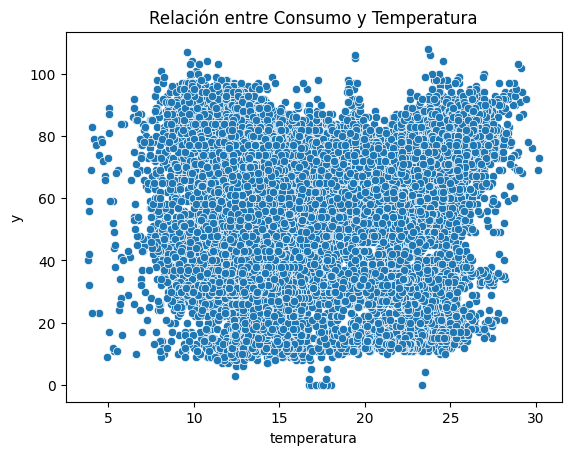

In [14]:
# Visualizar la relación entre consumo y temperatura
sns.scatterplot(x=df['temperatura'], y=df['y'])
plt.title('Relación entre Consumo y Temperatura')
plt.show()

# Análisis de Relaciones entre Variables
En esta sección, analizaremos las relaciones entre las variables del dataset para identificar cuáles son relevantes para el modelo Prophet.

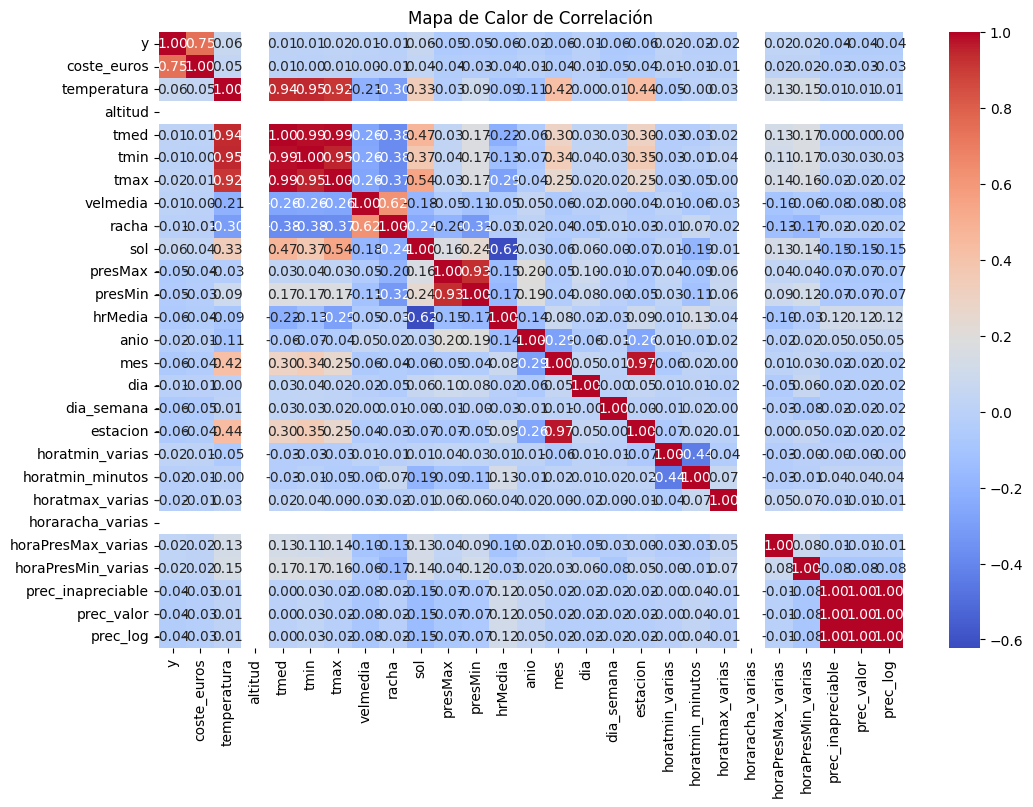

In [17]:
# Generar un mapa de calor de correlación
plt.figure(figsize=(12, 8))
# Seleccionar solo columnas numéricas
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Calor de Correlación')
plt.show()

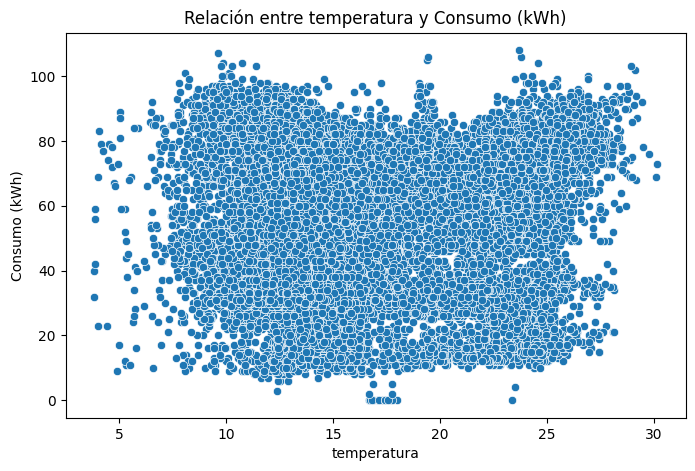

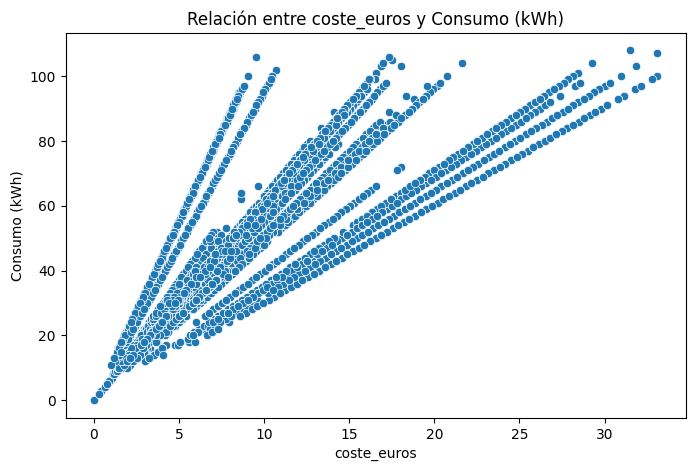

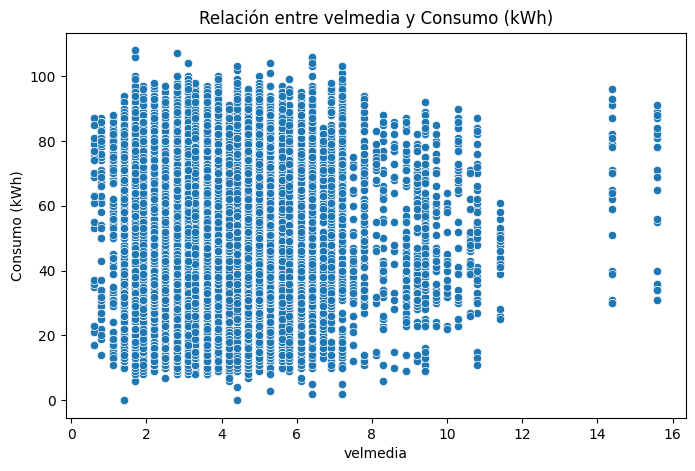

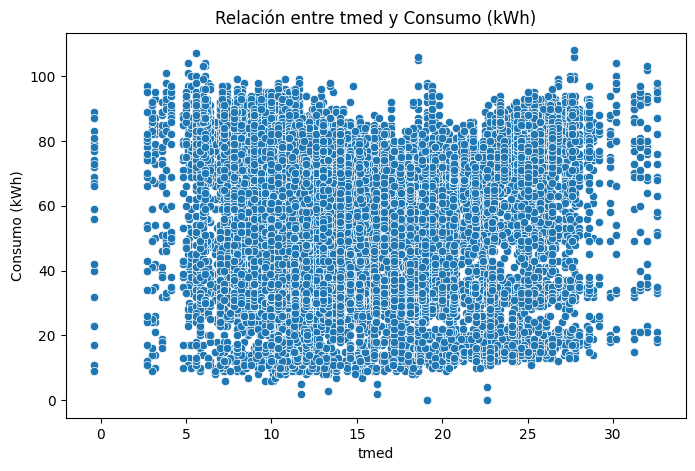

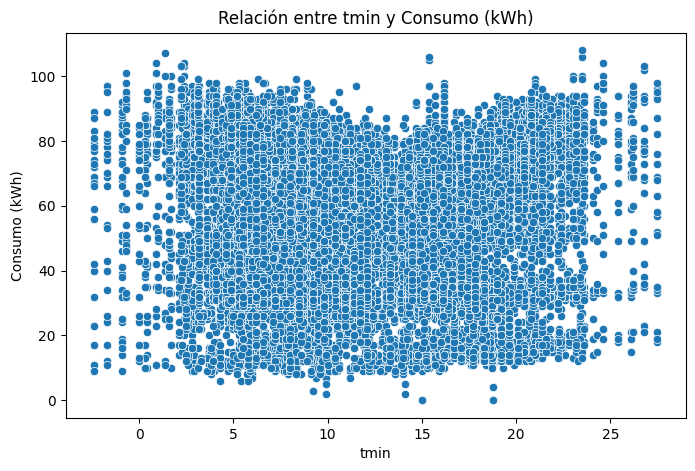

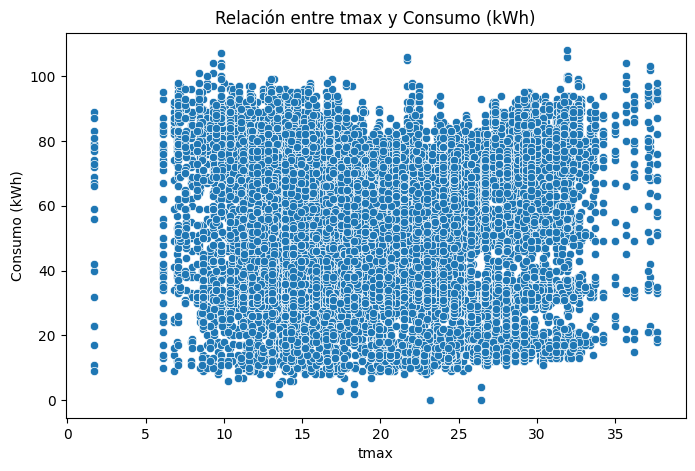

In [18]:
# Crear gráficos de dispersión para las variables más relevantes
variables_relevantes = ['temperatura', 'coste_euros', 'velmedia', 'tmed', 'tmin', 'tmax']
for var in variables_relevantes:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=df[var], y=df['y'])
    plt.title(f'Relación entre {var} y Consumo (kWh)')
    plt.xlabel(var)
    plt.ylabel('Consumo (kWh)')
    plt.show()

# Creación del Dataset para el Modelo Prophet
En esta sección, seleccionaremos las variables relevantes y crearemos un nuevo dataset para el modelo Prophet.

In [34]:
# Seleccionar las variables relevantes
variables_seleccionadas = ['ds', 'y', 'temperatura', 'coste_euros','tmin', 'tmax', 'velmedia','sol','racha','prec_log']
# Crear una copia independiente del DataFrame para evitar SettingWithCopyWarning
df_seleccionado = df[variables_seleccionadas].copy()

# Enriquecimiento del Dataset con Regresores
En esta sección, agregaremos medias móviles, tendencias, lags, día de la semana, fines de semana y festivos al dataset.

## LAGS

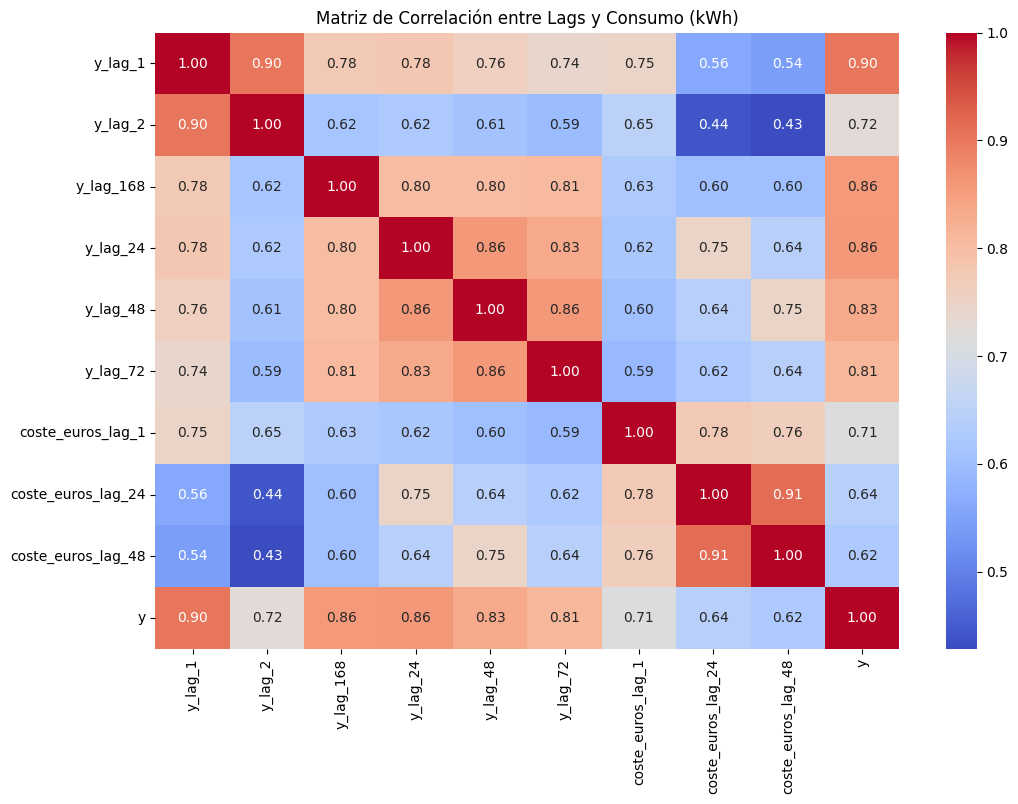

In [35]:
df_seleccionado['y_lag_1'] = df_seleccionado['y'].shift(1)
df_seleccionado['y_lag_2'] = df_seleccionado['y'].shift(2)
# df_seleccionado['y_lag_3'] = df_seleccionado['y'].shift(3)

#lag semana pasada en horas
df_seleccionado['y_lag_168'] = df_seleccionado['y'].shift(168)

#lag de 24 horas
df_seleccionado['y_lag_24'] = df_seleccionado['y'].shift(24)
df_seleccionado['y_lag_48'] = df_seleccionado['y'].shift(48)
df_seleccionado['y_lag_72'] = df_seleccionado['y'].shift(72)

# Crear lags para coste_euros
df_seleccionado['coste_euros_lag_1'] = df_seleccionado['coste_euros'].shift(1)
# df_seleccionado['coste_euros_lag_2'] = df_seleccionado['coste_euros'].shift(2)
# df_seleccionado['coste_euros_lag_3'] = df_seleccionado['coste_euros'].shift(3)
df_seleccionado['coste_euros_lag_24'] = df_seleccionado['coste_euros'].shift(24)
df_seleccionado['coste_euros_lag_48'] = df_seleccionado['coste_euros'].shift(48)
lag_columns = [col for col in df_seleccionado.columns if 'lag' in col] + ['y']

#crea una matriz de correlacion entre las variables lags y la variable y
correlation_matrix = df_seleccionado[lag_columns].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación entre Lags y Consumo (kWh)')
plt.show()


## MEDIAS MOVILES Y TREND

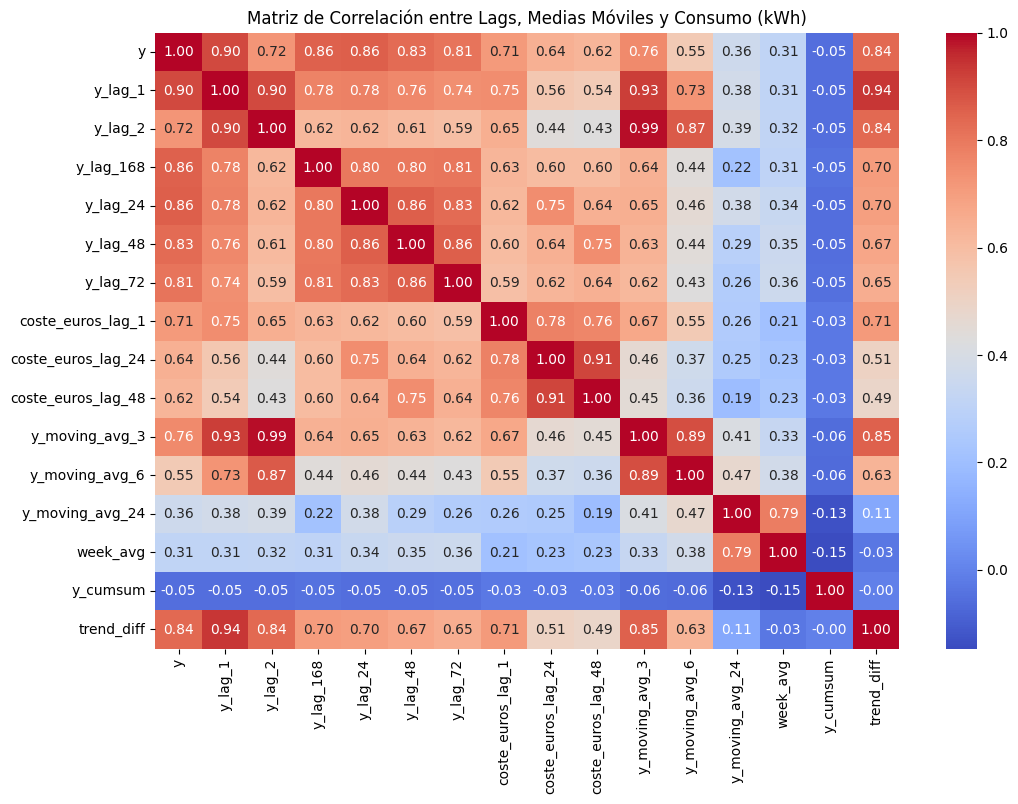

In [39]:
#generar medias moviles para la variable y
df_seleccionado['y_moving_avg_3'] = df_seleccionado['y'].shift(1).rolling(3).mean()
df_seleccionado['y_moving_avg_6'] = df_seleccionado['y'].shift(1).rolling(6).mean()   
df_seleccionado['y_moving_avg_24'] = df_seleccionado['y'].shift(1).rolling(24).mean()  

#week average
df_seleccionado['week_avg'] = df_seleccionado['y'].shift(1).rolling(168).mean()
# Calcular tendencia acumulativa para y
df_seleccionado['y_cumsum'] = df_seleccionado['y'].shift(1).cumsum()

df_seleccionado['trend_diff'] = df_seleccionado['y'].shift(1) - df_seleccionado['week_avg']

#calculame la matriz de correlacion de las variables de arriba, medias moviles week avergae y acumulativa
correlation_matrix = df_seleccionado[['y', 'y_lag_1', 'y_lag_2', 'y_lag_168', 'y_lag_24', 'y_lag_48', 'y_lag_72',
                                        'coste_euros_lag_1', 'coste_euros_lag_24', 'coste_euros_lag_48',
                                        'y_moving_avg_3', 'y_moving_avg_6', 'y_moving_avg_24',
                                        'week_avg', 'y_cumsum','trend_diff']].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación entre Lags, Medias Móviles y Consumo (kWh)')
plt.show()


## DIAS Y FESTIVOS

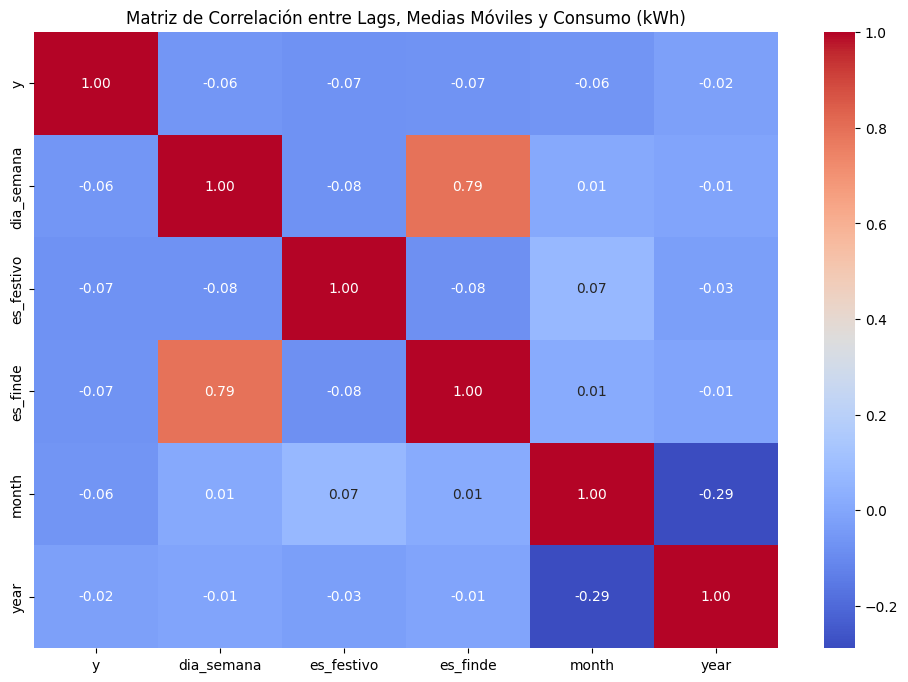

In [47]:
# Agregar día de la semana y si es fin de semana
df_seleccionado['dia_semana'] = pd.to_datetime(df_seleccionado['ds']).dt.dayofweek
df_seleccionado['es_finde'] = df_seleccionado['dia_semana'].apply(lambda x: 1 if x >= 5 else 0)

## agregar festivos de catalunya
catalunya_holidays = holidays.Spain(years=[2017, 2018, 2019, 2020, 2021, 2022, 2023], subdiv='CT')
df_seleccionado['es_festivo'] = df_seleccionado['ds'].apply(lambda x: 1 if pd.to_datetime(x).date() in catalunya_holidays else 0)
# Agregar variables de tendencia y estacionalidad
df_seleccionado['year'] =  pd.to_datetime(df_seleccionado['ds']).dt.year
df_seleccionado['month'] =  pd.to_datetime(df_seleccionado['ds']).dt.month


#calculame la matriz de correlacion de las variables de arriba, medias moviles week avergae y acumulativa
correlation_matrix = df_seleccionado[['y','dia_semana','es_festivo','es_finde', 'month','year']].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación entre Lags, Medias Móviles y Consumo (kWh)')
plt.show()



In [ ]:

df_seleccionado.dropna(inplace=True)
df_seleccionado.head()

,ds,y,temperatura,coste_euros,tmin,tmax,velmedia,sol,racha,prec_log,...,y_moving_avg_6,y_moving_avg_24,week_avg,y_cumsum,trend_diff,dia_semana,es_finde,es_festivo,year,month
168,2017-12-22 12:00:00,73.0,12.75,12.19757,7.8,14.2,9.4,5.1,14.2,0.0,...,55.500000,55.041667,54.910714,9225.0,14.089286,4,0,0,2017,12
169,2017-12-22 13:00:00,70.0,13.18,6.30140,7.8,14.2,9.4,5.1,14.2,0.0,...,61.333333,55.083333,54.952381,9298.0,18.047619,4,0,0,2017,12
170,2017-12-22 14:00:00,71.0,13.50,6.43828,7.8,14.2,9.4,5.1,14.2,0.0,...,65.500000,55.000000,54.946429,9368.0,15.053571,4,0,0,2017,12
171,2017-12-22 15:00:00,75.0,13.68,7.86600,7.8,14.2,9.4,5.1,14.2,0.0,...,69.166667,54.833333,54.916667,9439.0,16.083333,4,0,0,2017,12
172,2017-12-22 16:00:00,70.0,13.68,11.44850,7.8,14.2,9.4,5.1,14.2,0.0,...,71.000000,54.708333,54.898810,9514.0,20.101190,4,0,0,2017,12


# Modelo Prophet con Cross-Validation
En esta sección, crearemos un modelo Prophet utilizando las variables del dataset, realizaremos un cross-validation y evaluaremos las métricas de rendimiento.

In [2]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Cargar el dataset seleccionado
df = pd.read_csv('df_seleccionado.csv')
# df['ds'] = pd.to_datetime(df['ds'])

In [4]:

regresores = ['temperatura', 'coste_euros', 'tmin', 'tmax', 'velmedia', 'sol', 'racha', 'prec_log',
             'y_lag_1', 'y_lag_2', 'y_lag_168', 'y_lag_24', 'y_lag_48', 'y_lag_72',
             'coste_euros_lag_1', 'coste_euros_lag_24', 'coste_euros_lag_48',
             'y_moving_avg_3', 'y_moving_avg_6', 'y_moving_avg_24',
             'week_avg', 'y_cumsum', 'trend_diff', 'dia_semana', 'es_finde', 'es_festivo', 'year', 'month']



In [10]:
from itertools import product


param_grid = {                       
    'changepoint_prior_scale': [0.05],
    'seasonality_prior_scale': [3],
    'seasonality_mode': ['additive',  'multiplicative'],
    'changepoint_range': [0.9],
    'n_changepoints': [20],
}

# Combinaciones del grid
all_params = [
    dict(zip(param_grid.keys(), v))
    for v in product(*param_grid.values())
]


In [11]:
results = []             # guardamos métricas de cada combinación

for params in all_params:
    m = Prophet(
        daily_seasonality=False,
        weekly_seasonality=False,
        yearly_seasonality=False,
        **params
    )

    # Re‐gresores
    for reg in regresores:
        m.add_regressor(reg)
    m.add_seasonality('daily',  period=1, fourier_order=16)
    m.add_seasonality('weekly', period=7, fourier_order=10)
    m.add_seasonality('monthly', period=30.5, fourier_order=5)
    m.add_seasonality('yearly', period=365.25, fourier_order=5)

    m.fit(df)

    cv = cross_validation(
        m,
        initial='400 days',
        period='24 hours',
        horizon='24 hours',
        parallel='processes'
    )
    perf = performance_metrics(cv, rolling_window=1)   # media simple
    results.append({
        **params,
        'rmse': perf['rmse'].mean(),
        'mape': perf['mape'].mean()
    })

cv_grid = pd.DataFrame(results).sort_values('rmse')
print(cv_grid.head())

12:24:47 - cmdstanpy - INFO - Chain [1] start processing
12:26:11 - cmdstanpy - INFO - Chain [1] done processing
13:12:39 - cmdstanpy - INFO - Chain [1] start processing
13:12:55 - cmdstanpy - INFO - Chain [1] done processing


   changepoint_prior_scale  seasonality_prior_scale seasonality_mode  \
0                     0.05                        3         additive   
1                     0.05                        3   multiplicative   

   changepoint_range  n_changepoints      rmse      mape  
0                0.9              20  2.898966  0.043103  
1                0.9              20  2.899827  0.043287  


In [12]:
cv_grid = pd.DataFrame(results).sort_values('rmse')
display(cv_grid.head(10))

,changepoint_prior_scale,seasonality_prior_scale,seasonality_mode,changepoint_range,n_changepoints,rmse,mape
0,0.05,3,additive,0.9,20,2.898966,0.043103
1,0.05,3,multiplicative,0.9,20,2.899827,0.043287


In [ ]:
# Crear el modelo Prophet
m = Prophet(
    daily_seasonality=False,   # Desactivamos las automáticas para controlarlas a mano
    weekly_seasonality=False,
    yearly_seasonality=False
)
for reg in regresores:
    m.add_regressor(reg)

# Estacionalidad diaria (periodo = 1 día) – 15 armónicos ≈ captura hasta ciclos de 1.6 h
m.add_seasonality(name='daily', period=1, fourier_order=16)

# Estacionalidad semanal completa
m.add_seasonality(name='weekly', period=7, fourier_order=10)

# Estacionalidad mensual completa
m.add_seasonality(name='monthly', period=30.5, fourier_order=10)    
# Entrenar el modelo
m.fit(df)

In [ ]:
# Realizar cross-validation
cv_results = cross_validation(
    m,
    initial='600days',
    period='1 days',
    horizon='72 hours',
    parallel='processes'          
)

# Calcular métricas de rendimiento
metrics = performance_metrics(cv_results)
print(metrics)

           horizon        mse      rmse       mae      mape     mdape  \
0  0 days 03:00:00   2.258344  1.502779  1.230962  0.045147  0.037793   
1  0 days 04:00:00   1.787681  1.337042  1.046924  0.034396  0.025411   
2  0 days 05:00:00   1.142630  1.068939  0.816211  0.024733  0.019092   
3  0 days 06:00:00   1.018122  1.009020  0.773569  0.021269  0.017238   
4  0 days 07:00:00   1.142124  1.068702  0.841184  0.021483  0.016607   
5  0 days 08:00:00   2.444120  1.563368  1.185969  0.027253  0.019022   
6  0 days 09:00:00   2.461115  1.568794  1.188021  0.024422  0.016540   
7  0 days 10:00:00   3.026502  1.739684  1.274422  0.022500  0.014386   
8  0 days 11:00:00   4.990868  2.234025  1.580893  0.026755  0.015403   
9  0 days 12:00:00   6.364048  2.522706  1.781111  0.031530  0.016448   
10 0 days 13:00:00  21.228395  4.607428  2.921158  0.062696  0.022860   
11 0 days 14:00:00  30.765565  5.546672  3.750572  0.086405  0.030984   
12 0 days 15:00:00  29.795115  5.458490  3.818177  

In [60]:
#calcular metricas cde rendimiento las medias
metrics_mean = metrics.mean()
print(metrics_mean)

horizon     0 days 13:30:00
mse                8.918298
rmse               2.624918
mae                1.887692
mape               0.041959
mdape              0.023424
smape              0.041184
coverage           0.834469
dtype: object


In [63]:
# Calcular métricas adicionales: MAPE, Coverage
cv_results['error'] = cv_results['yhat'] - cv_results['y']
cv_results['mape'] = np.abs(cv_results['error']) / cv_results['y']
coverage = np.mean((cv_results['y'] >= cv_results['yhat_lower']) & (cv_results['y'] <= cv_results['yhat_upper']))
print(f'Coverage: {coverage:.2%}')
print(f'MAPE: {np.mean(cv_results["mape"]):.2%}')
# Graficar las métricas de rendimientoç

Coverage: 84.26%
MAPE: 4.26%


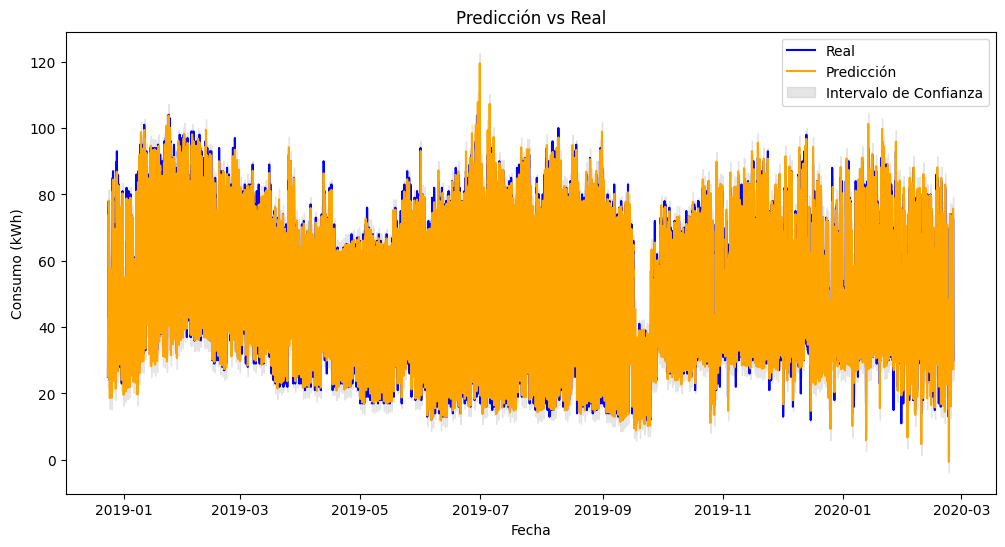

In [64]:
#hazme un grafico de la variable predicada y la real
plt.figure(figsize=(12, 6))
plt.plot(cv_results['ds'], cv_results['y'], label='Real', color='blue')
plt.plot(cv_results['ds'], cv_results['yhat'], label='Predicción', color='orange')
plt.fill_between(cv_results['ds'], cv_results['yhat_lower'], cv_results['yhat_upper'], color='gray', alpha=0.2, label='Intervalo de Confianza')
plt.title('Predicción vs Real')
plt.xlabel('Fecha')
plt.ylabel('Consumo (kWh)')
plt.legend()
plt.show()

In [66]:
!pip install plotly

   ---------------------------------------- 0.0/14.8 MB ? eta -:--:--
   -------- ------------------------------- 3.1/14.8 MB 18.5 MB/s eta 0:00:01
   -------------------- ------------------- 7.6/14.8 MB 21.4 MB/s eta 0:00:01
   ------------------------------- -------- 11.8/14.8 MB 21.1 MB/s eta 0:00:01
   ---------------------------------------- 14.8/14.8 MB 19.0 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Crear un gráfico interactivo con Plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'browser'
# Crear gráfico interactivo
fig = go.Figure()
fig.add_trace(go.Scatter(x=cv_results['ds'], y=cv_results['y'], mode='lines', name='Real', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=cv_results['ds'], y=cv_results['yhat'], mode='lines', name='Predicción', line=dict(color='orange')))
fig.update_layout(title='Predicción vs Real (Interactividad)',
                  xaxis_title='Fecha',
                  yaxis_title='Consumo (kWh)',
                  legend_title='Leyenda')

In [75]:
#hazme un grafico de la variable predicha y valor real que sea interactivo pero para solo 3 dias
# Filtrar los resultados para los últimos 3 días
last_3_days = cv_results[cv_results['ds'] >= (cv_results['ds'].max() - pd.Timedelta(days=120))].copy()
# Crear gráfico interactivo
fig = go.Figure()
fig.add_trace(go.Scatter(x=last_3_days['ds'], y=last_3_days['y'], mode='lines', name='Real', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=last_3_days['ds'], y=last_3_days['yhat'], mode='lines', name='Predicción', line=dict(color='orange')))
fig.update_layout(title='Predicción vs Real',
                  xaxis_title='Fecha',
                  yaxis_title='Consumo (kWh)',
                  legend_title='Leyenda')
fig.show()
